In [10]:
import pandas as pd
from collections import Counter
import numpy as np
from matplotlib.table import table
from sklearn.neighbors import KernelDensity
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid_spec
import jinja2
import re
import tabulate
import ridgeplot as rg
import nbformat
from sympy import true

import seaborn as sns
import plotly.io as pio
pio.renderers.default = "notebook"
from IPython.display import IFrame
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
#a

In [12]:
df = pd.read_csv("pedestrian_cyclist_collisions.csv")
print(df.columns)
print(df.shape)

df['Serious_and_Fatal_Injuries'] = df['NumberOfFatalities'] + df['NumberOfSeriousInjuries']

df_seriousinj_fatals = df[df['Serious_and_Fatal_Injuries'] > 0]

print(df_seriousinj_fatals.shape)


Index(['Unnamed: 0', 'CaseNumber', 'CaseYear', 'CrashDate', 'CrashTime',
       'CrashTimeFormatted', 'CrashTypeCde', 'CrashType', 'CollisionType',
       'CrashSeverity', 'LightCondition', 'WeatherCondition',
       'RoadwayAccessControlCde', 'RoadwayCharacteristic',
       'RoadSurfaceCondition', 'TrafficControl', 'TrafficWay',
       'MaxInjurySeverity', 'NumberOfFatalities', 'NumberOfInjuries',
       'NumberOfSeriousInjuries', 'NumberOfOtherInjuries', 'NumberOfVehicles',
       'PoliceDept', 'ReportingAgency', 'Precinct',
       'CommercialVehicleCrashInd', 'PPDRCode', 'NonReportable',
       'ReviewedIndicator', 'DMVInsertDate', 'CountyFIPS', 'CountyName',
       'MuniFIPS', 'CityTownName', 'OnStreet', 'ClosestCrossStreet',
       'MasterIntersectionId', 'IntersectionIndicator', 'ReferenceMarker',
       'DistanceFromIntersection', 'DirectionFromIntersection', 'UTMEasting',
       'UTMNorthing', 'NonPublicWayCode', 'ACCESS_CONTROL', 'DIVIDED',
       'FUNCTIONAL_CLASS', 'MAINT_JU

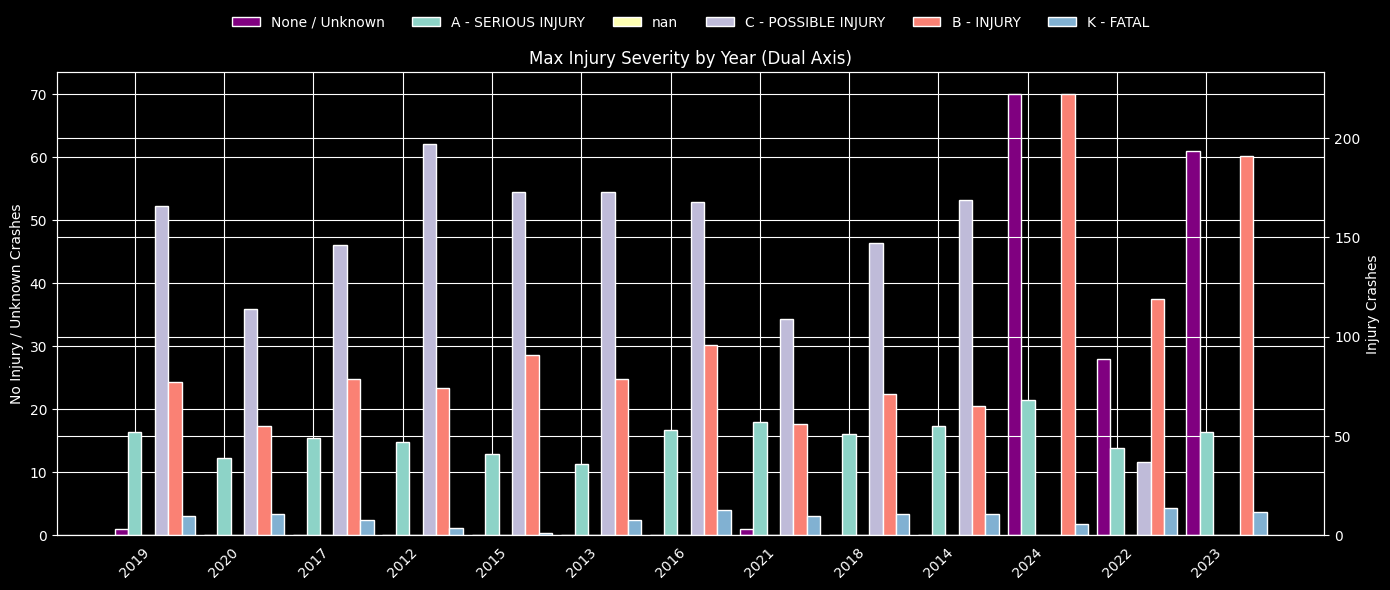

In [17]:
# Replace Unknown with None
years = df['CaseYear'].unique()

df['MaxInjurySeverity'] = (
    df['MaxInjurySeverity']
    .replace("U - UNKNOWN", "None")
)

maxinjuries = df['MaxInjurySeverity'].unique()

primary_category = "None"
secondary_categories = [cat for cat in maxinjuries if cat != primary_category]

x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

width = 0.15

# ---- PRIMARY AXIS (None / Unknown) ----
none_counts = [
    df[
        (df["CaseYear"] == year) &
        (df["MaxInjurySeverity"] == primary_category)
    ]["MaxInjurySeverity"].count()
    for year in years
]

ax1.bar(
    x - width,
    none_counts,
    width,
    label="None / Unknown",
    color="purple"     # ← Purple as requested
)

ax1.set_ylabel("No Injury / Unknown Crashes")

# ---- SECONDARY AXIS (Actual Injuries) ----
for i, category in enumerate(secondary_categories):

    counts = [
        df[
            (df["CaseYear"] == year) &
            (df["MaxInjurySeverity"] == category)
        ]["MaxInjurySeverity"].count()
        for year in years
    ]

    ax2.bar(
        x + (i * width),
        counts,
        width,
        label=category
    )

ax2.set_ylabel("Injury Crashes")

# Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45)
ax1.set_title("Max Injury Severity by Year (Dual Axis)")

# ---- HORIZONTAL LEGEND ABOVE PLOT ----
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),  # push above plot
    ncol=len(labels1 + labels2), # stretch horizontally
    frameon=False
)

plt.tight_layout()

# Save figure as PDF
pdf_file = "MaxInjurySeverityPYear.pdf"
plt.savefig(pdf_file, bbox_inches='tight')  # tight layout to fit table nicely
plt.show()